In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install numpy==1.26.4 --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'd:\\practisexcode\\lib\\site-packages\\numpy.libs\\libscipy_openblas64_-63c857e738469261263c764a36be9436.dll'
Consider using the `--user` option or check the permissions.



In [9]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

<!doctype html>
<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">
  <head >
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width,initial-scale=1,minimum-scale=1">
    <meta http-equiv="X-UA-Compatible" content="IE=edge"> 
    <link rel="manifest" href="/assets/next/manifest.json">
    <style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
    <script src="/static/js/env-runtime.js" defer></script>
    <script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
    <script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>
    <title>Top Companies in India | AmbitionBox</title><meta data-n-head="ssr" name="copyright" content="2026 AmbitionBox"><meta data-n-head="ssr" name="revisit-after" content="1 day"><meta data-n-head="ss
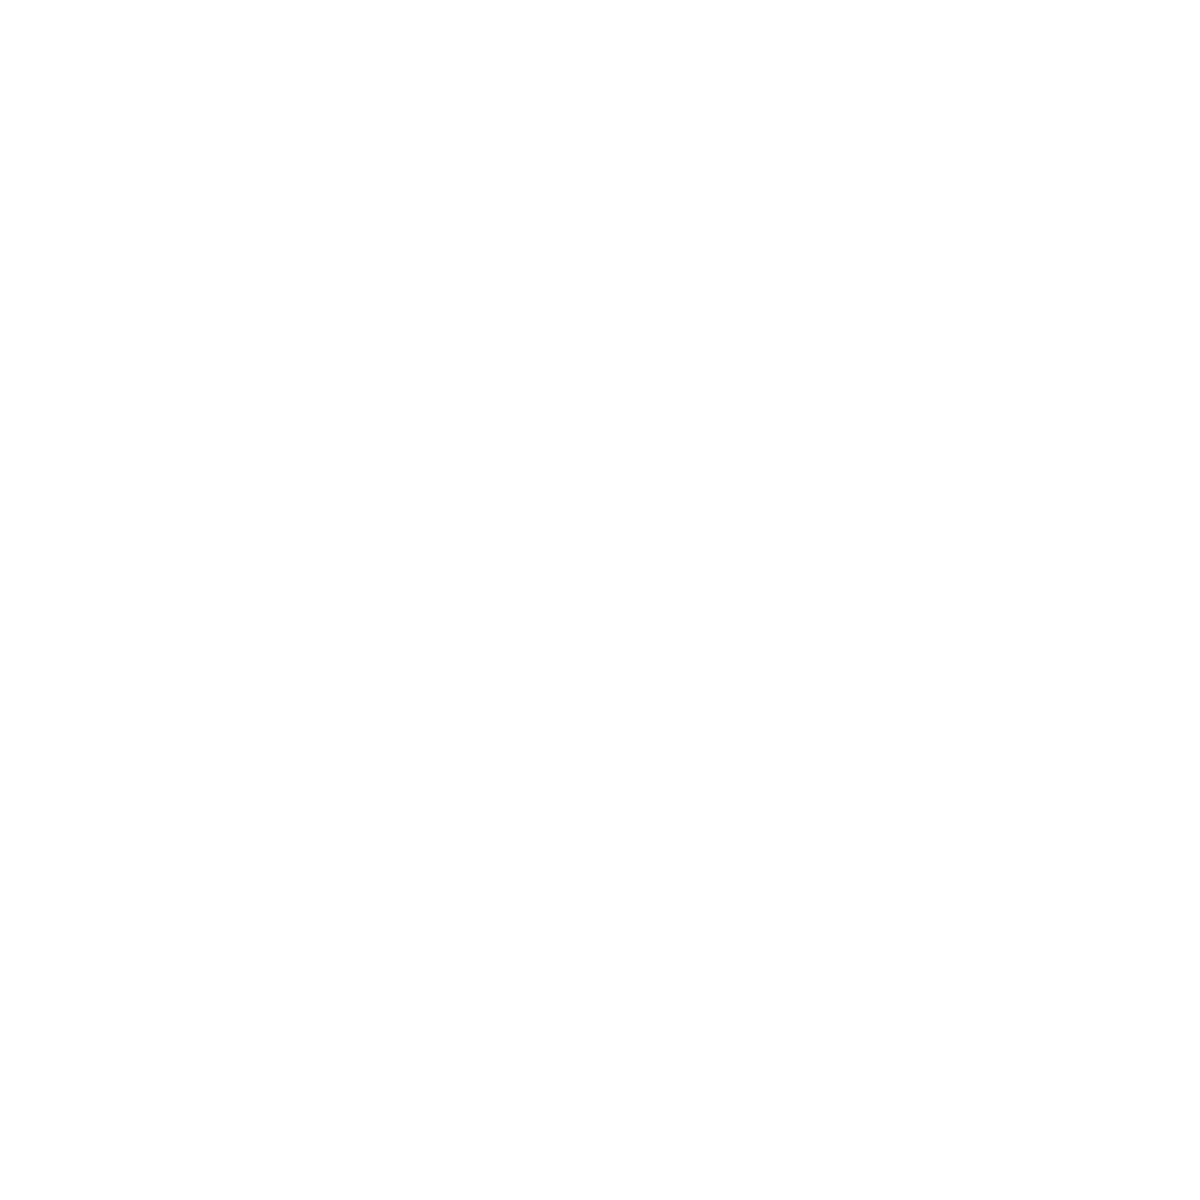

In [10]:
# fetching html code from the browser ( ambitionbox.com ) -> for 1st page only
headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36'}
webpage=requests.get('https://www.ambitionbox.com/list-of-companies?page=1',headers = headers)
print(webpage.text)

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-a
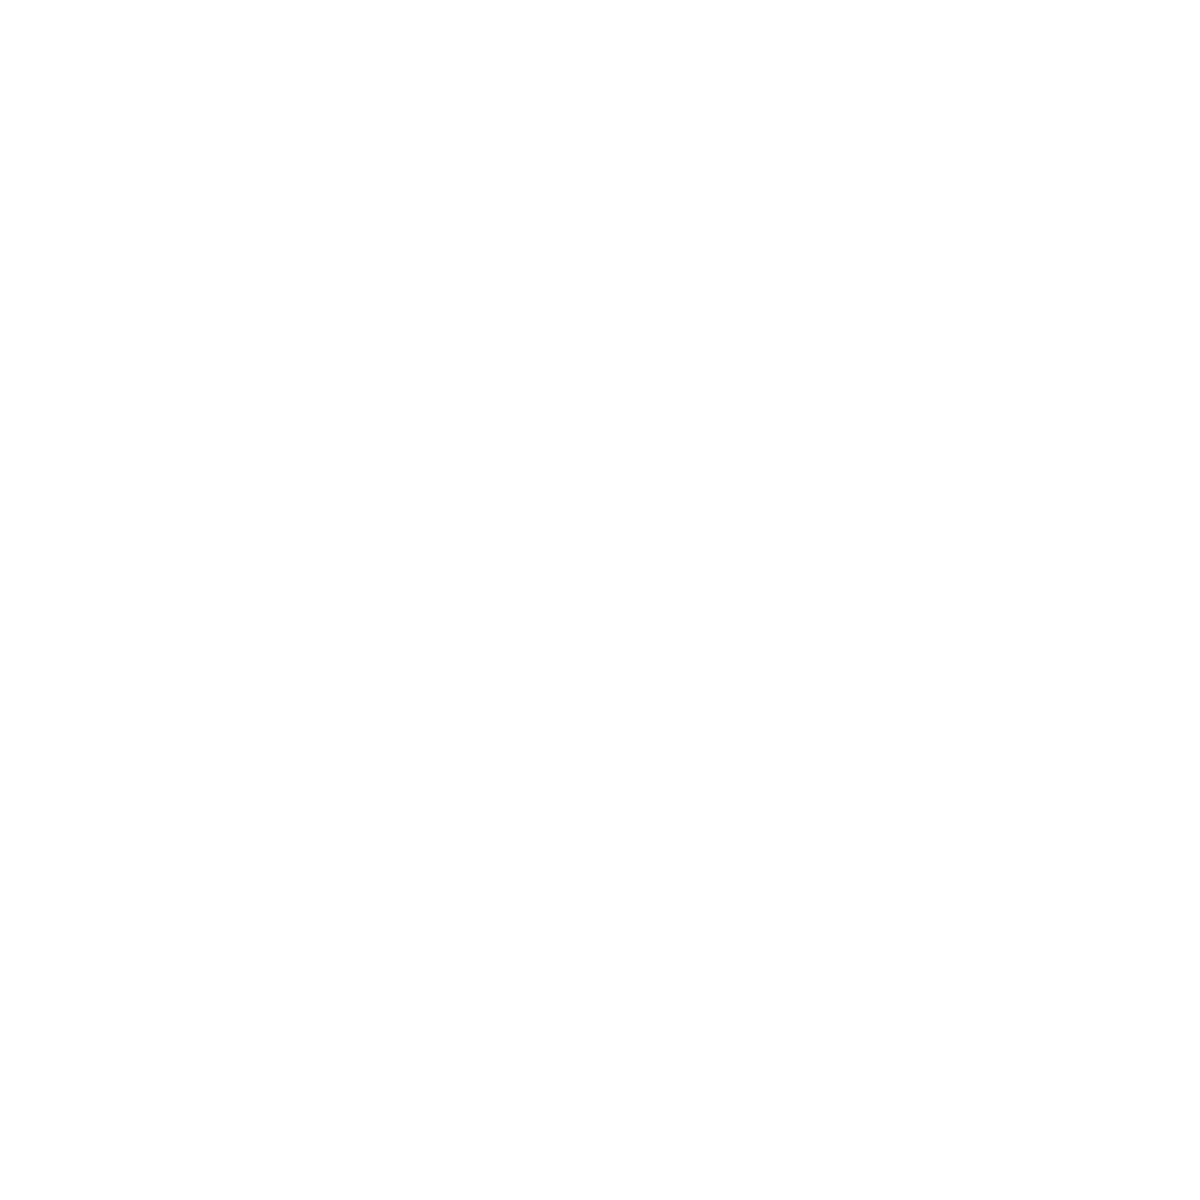

In [11]:
# structing the html in perfect way
soup=BeautifulSoup(webpage.text, 'lxml')
print(soup.prettify())

In [12]:
# class of specific company and length
company=soup.find_all('div', class_='companyCardWrapper__primaryInformation')
len(company)

20

In [13]:
name=[]   # name of the company
rating=[]    # rating of the company
reviews=[]   # reviews fo company
ctype=[]   # type -> public or private
hq=[]   # head quarter of the company
old=[]    # how old the company is 
employees=[]    # number of employees

for i in company:    # loop is running every div one by one
    name.append(i.find('h2').text.strip())    # fetching company name  
    rating.append(i.find_all('div', class_='rating_star_container')[0].text.strip())   #fetching ratings of company from the browser 
    reviews.append(i.find('span', class_='companyCardWrapper'))   # review this code -> not give correct result
    ctype.append(i.find_all('span',class_='companyCardWrapper__interLinking')[0].text.strip())
    hq.append(i.find_all('span', class_='companyCardWrapper__interLinking')[0].text.strip())
    old.append(i.find_all('span', class_='companyCardWrapper__interLinking')[0].text.strip())
    try:
        employees.append(i.find_all('span', class_='companyCardWrapper__interLinking')[0].text.strip())
    except:
        employees.append(np,nan)    # one less employee value so added try except

d={'name':name, 'rating':rating, 'reviews':reviews, 'type':ctype, 'hq':hq, 'old':old, 'employees':employees}
df=pd.DataFrame(d)
df


# this is demo code by which we can perform web scraping on any website to get their information according to requirement by using inspect function of the web site

,name,rating,reviews,type,hq,old,employees
0,TCS,3.3,None,IT Services & Consulting | Bengaluru +440 othe...,IT Services & Consulting | Bengaluru +440 othe...,IT Services & Consulting | Bengaluru +440 othe...,IT Services & Consulting | Bengaluru +440 othe...
1,Accenture,3.7,None,IT Services & Consulting | Bengaluru +257 othe...,IT Services & Consulting | Bengaluru +257 othe...,IT Services & Consulting | Bengaluru +257 othe...,IT Services & Consulting | Bengaluru +257 othe...
2,Wipro,3.6,None,IT Services & Consulting | Hyderabad +371 othe...,IT Services & Consulting | Hyderabad +371 othe...,IT Services & Consulting | Hyderabad +371 othe...,IT Services & Consulting | Hyderabad +371 othe...
3,Cognizant,3.7,None,IT Services & Consulting | Hyderabad +234 othe...,IT Services & Consulting | Hyderabad +234 othe...,IT Services & Consulting | Hyderabad +234 othe...,IT Services & Consulting | Hyderabad +234 othe...
4,Capgemini,3.7,None,IT Services & Consulting | Bengaluru +182 othe...,IT Services & Consulting | Bengaluru +182 othe...,IT Services & Consulting | Bengaluru +182 othe...,IT Services & Consulting | Bengaluru +182 othe...
5,HDFC Bank,3.8,None,Banking | Mumbai +1840 other locations,Banking | Mumbai +1840 other locations,Banking | Mumbai +1840 other locations,Banking | Mumbai +1840 other locations
6,Infosys,3.5,None,IT Services & Consulting | Bengaluru +248 othe...,IT Services & Consulting | Bengaluru +248 othe...,IT Services & Consulting | Bengaluru +248 othe...,IT Services & Consulting | Bengaluru +248 othe...
7,ICICI Bank,4.0,None,Banking | Mumbai +1441 other locations,Banking | Mumbai +1441 other locations,Banking | Mumbai +1441 other locations,Banking | Mumbai +1441 other locations
8,HCLTech,3.4,None,IT Services & Consulting | Chennai +233 other ...,IT Services & Consulting | Chennai +233 other ...,IT Services & Consulting | Chennai +233 other ...,IT Services & Consulting | Chennai +233 other ...
9,Tech Mahindra,3.4,None,IT Services & Consulting | Hyderabad +330 othe...,IT Services & Consulting | Hyderabad +330 othe...,IT Services & Consulting | Hyderabad +330 othe...,IT Services & Consulting | Hyderabad +330 othe...


in the bottom their is some function also performed related to the functions that require during web scraping

In [48]:
soup.find_all('h2')  # fetching h2 (heading)

[<h2 class="companyListing__title">
 								Companies in India
 							</h2>,
 <h2 class="companyCardWrapper__companyName" title="TCS">
 										TCS
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Accenture">
 										Accenture
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Wipro">
 										Wipro
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Cognizant">
 										Cognizant
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Capgemini">
 										Capgemini
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="HDFC Bank">
 										HDFC Bank
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Infosys">
 										Infosys
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="ICICI Bank">
 										ICICI Bank
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="HCLTech">
 										HCLTech
 									</h2>,
 <h2 class="companyCardWrappe

In [28]:
for i in soup.find_all('h2'):
    print(i.text.strip())  # strip makes gap free output

Companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
ICICI Bank
HCLTech
Tech Mahindra
Genpact
TP
Jio
Axis Bank
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTIMindtree
IBM
Popular Collections by Industries
Popular Collections by Cities
Popular Collections by Roles


In [49]:
soup.find_all('div', class_='rating_star_container')   # fetching classes and checking classes using inspect in browser

[<div class="rating_star_container" style="line-height:20px;"><svg fill="none" height="20" viewbox="0 0 20 20" width="20" xmlns="http://www.w3.org/2000/svg"><rect fill="#FFBA01" height="20" rx="4" width="20"></rect> <path d="M6.295 16L7.27 11.5632L4 8.57895L8.32 8.18421L10 4L11.68 8.18421L16 8.57895L12.73 11.5632L13.705 16L10 13.6474L6.295 16Z" fill="white"></path></svg> <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.3<!-- --></div></div></div>,
 <div class="rating_star_container" style="line-height:20px;"><svg fill="none" height="20" viewbox="0 0 20 20" width="20" xmlns="http://www.w3.org/2000/svg"><rect fill="#9acd32" height="20" rx="4" width="20"></rect> <path d="M6.295 16L7.27 11.5632L4 8.57895L8.32 8.18421L10 4L11.68 8.18421L16 8.57895L12.73 11.5632L13.705 16L10 13.6474L6.295 16Z" fill="white"></path></svg> <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.7<!-- --></div></div></div>,
 <div class="rating_star_container" style="lin

In [146]:
soup.find_all('span', class_='companyCardWrapper__ActionTitle') # fetching reviews

[<span class="companyCardWrapper__ActionTitle">Reviews</span>,
 <span class="companyCardWrapper__ActionTitle">Salaries</span>,
 <span class="companyCardWrapper__ActionTitle">Interviews</span>,
 <span class="companyCardWrapper__ActionTitle">Jobs</span>,
 <span class="companyCardWrapper__ActionTitle">Benefits</span>,
 <span class="companyCardWrapper__ActionTitle">Photos</span>,
 <span class="companyCardWrapper__ActionTitle">Reviews</span>,
 <span class="companyCardWrapper__ActionTitle">Salaries</span>,
 <span class="companyCardWrapper__ActionTitle">Interviews</span>,
 <span class="companyCardWrapper__ActionTitle">Jobs</span>,
 <span class="companyCardWrapper__ActionTitle">Benefits</span>,
 <span class="companyCardWrapper__ActionTitle">Photos</span>,
 <span class="companyCardWrapper__ActionTitle">Reviews</span>,
 <span class="companyCardWrapper__ActionTitle">Salaries</span>,
 <span class="companyCardWrapper__ActionTitle">Interviews</span>,
 <span class="companyCardWrapper__ActionTitle">Jo

FETCHING DATA FOR 50 PAGES

In [16]:
final=pd.DataFrame(d)
for j in range(1,50):
    url='https://www.ambitionbox.com/list-of-companies?page={}'.format(j)

    headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36'}
    webpage=requests.get(url, headers = headers).text
    
    soup=BeautifulSoup(webpage, 'lxml')

    company=soup.find_all('div', class_='companyCardWrapper__primaryInformation')

    name=[]   # name of the company
    rating=[]    # rating of the company
    reviews=[]   # reviews fo company
    ctype=[]   # type -> public or private
    hq=[]   # head quarter of the company
    old=[]    # how old the company is 
    employees=[]    # number of employees
    
    for i in company:    # loop is running every div one by one
        name.append(i.find('h2').text.strip())    # fetching company name  
        rating.append(i.find_all('div', class_='rating_star_container')[0].text.strip())   #fetching ratings of company from the browser 
        reviews.append(i.find('span', class_='companyCardWrapper'))   # review this code -> not give correct result
        ctype.append(i.find_all('span',class_='companyCardWrapper__interLinking')[0].text.strip())
        hq.append(i.find_all('span', class_='companyCardWrapper__interLinking')[0].text.strip())
        old.append(i.find_all('span', class_='companyCardWrapper__interLinking')[0].text.strip())
        try:
            employees.append(i.find_all('span', class_='companyCardWrapper__interLinking')[0].text.strip())
        except:
            employees.append(np,nan)    # one less employee value so added try except
    
    d={'name':name, 'rating':rating, 'reviews':reviews, 'type':ctype, 'hq':hq, 'old':old, 'employees':employees}
    
    

    df = pd.DataFrame(d)
    final = pd.concat([final, df], ignore_index=True)
    
    print(final)

                             name rating reviews  \
0              Innominds Software    3.2    None   
1    Navin Fluorine International    3.8    None   
2                  General Motors    4.0    None   
3   BLK Super Speciality Hospital    3.9    None   
4                          Practo    3.0    None   
5                       Inox Wind    3.7    None   
6                   FiveS Digital    3.4    None   
7                       Carlsberg    4.0    None   
8                     LendingKart    3.6    None   
9           Propertypistol Realty    3.8    None   
10            GSPANN Technologies    4.1    None   
11            L & W Constructions    3.9    None   
12  Datamatics Business Solutions    3.3    None   
13            Bharat Fritz Werner    3.9    None   
14         Enco Engineers Combine    3.7    None   
15                 Unified Mentor    4.1    None   
16           Craftsman Automation    3.8    None   
17         Kellogg Brown and Root    4.1    None   
18          

In [17]:
final.shape  # shape of the 50 pages

(1000, 7)